# Assignment 4


**Student Name:** Sheylle Green and Marc Wijnands 

**Group Number:** 20

In [10]:
import diplib as dip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Part 1

### Question 1 — Segmentation of 15 cells in the Control Series (frame 0)


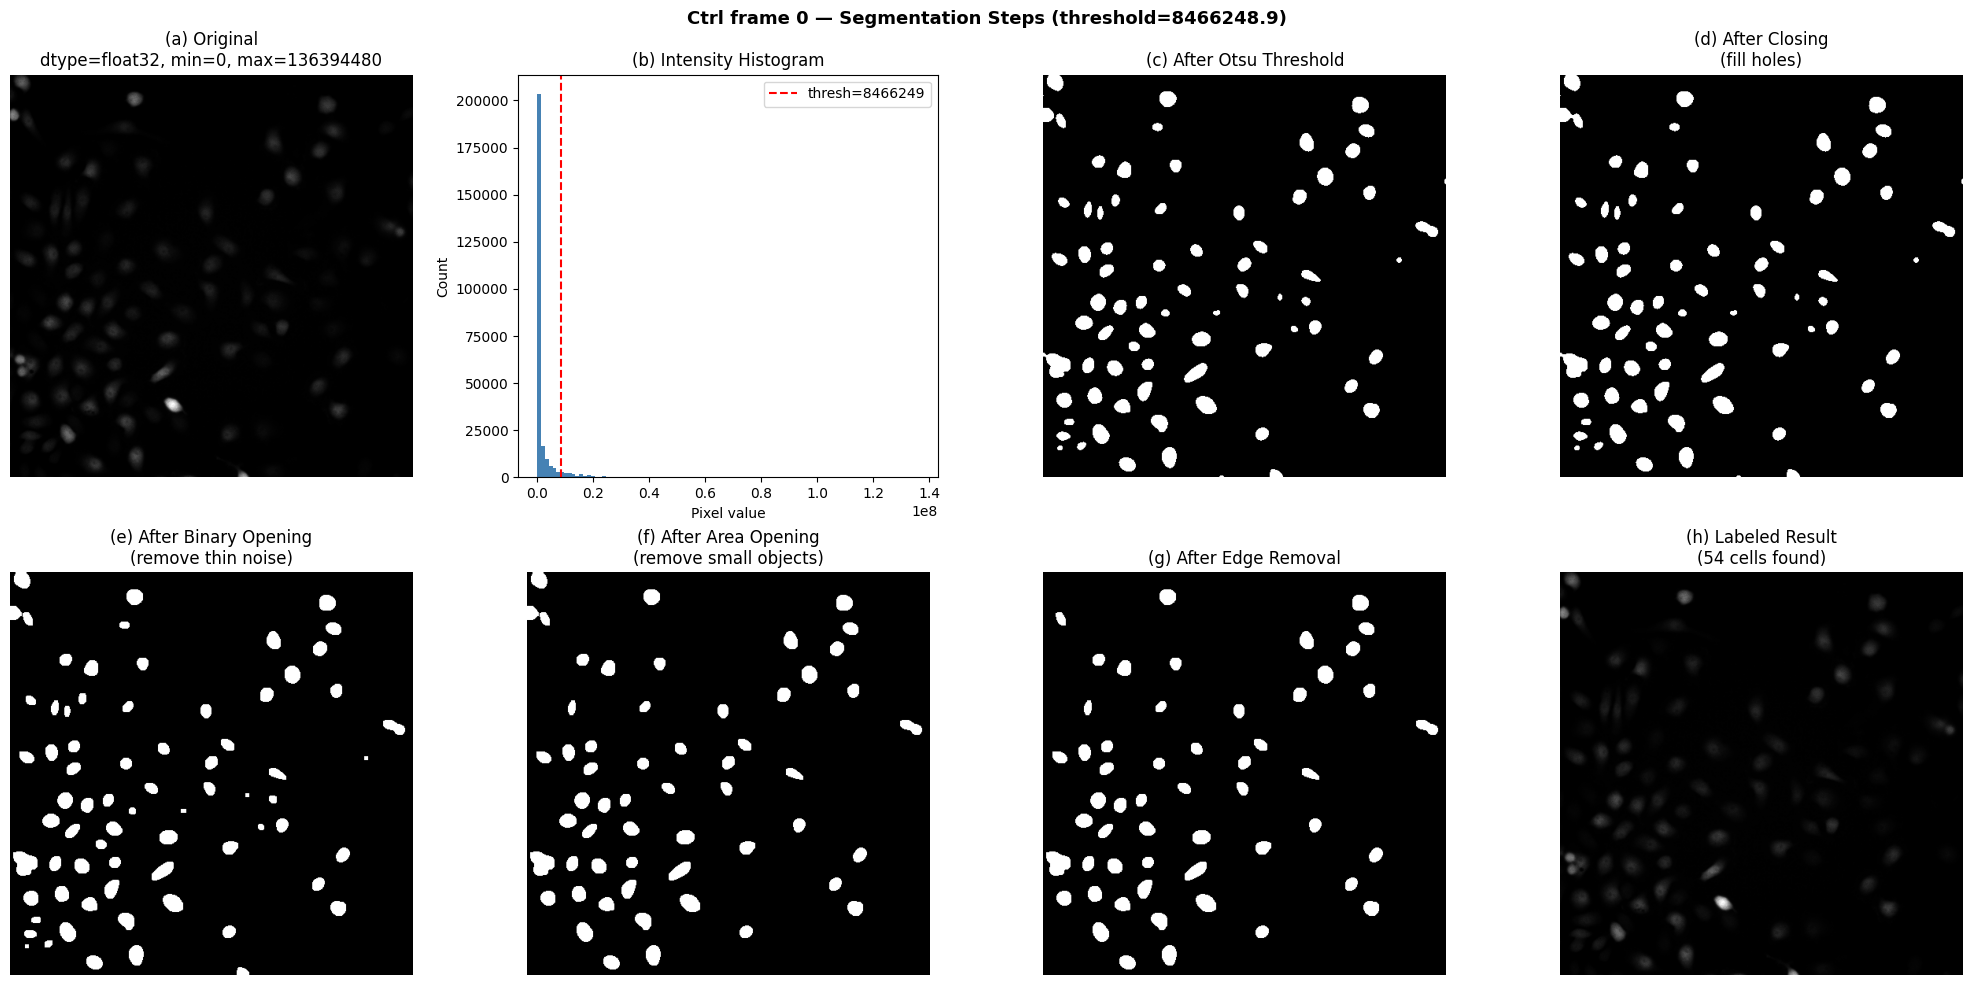

Otsu threshold : 8466248.9
Total cells found: 54
Image dtype : float32
Intensity range: 0 – 136394480


In [39]:
def segment_cells(filepath, plot=False, imgname='frame'):
    img = dip.ImageReadTIFF(filepath)

    if img.TensorElements() > 1:
        img = dip.ColorSpaceManager.Convert(img, 'gray')

    arr_orig = np.array(img)

    # Step 1: Smooth
    smoothed = dip.Gauss(img, [2])

    # Step 2: Otsu threshold
    binary, thresh_val = dip.Threshold(smoothed)
    thresh_val = float(thresh_val)

    # Step 3: Close holes
    closed = dip.Closing(binary, dip.SE(5, 'elliptic'))

    # Step 4a: Binary opening
    opened = dip.BinaryOpening(closed, connectivity=2, iterations=2)

    # Step 4b: Remove small objects
    area_opened = dip.AreaOpening(opened, filterSize=150)

    # Step 5: Remove border cells
    no_border = dip.EdgeObjectsRemove(area_opened)

    # Step 6: Label
    labeled = dip.Label(no_border, connectivity=2)
    label_arr = np.array(labeled)

    if plot:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle(f'{imgname} — Segmentation Steps (threshold={thresh_val:.1f})',
                     fontsize=13, fontweight='bold')

        # (a) Original
        axes[0,0].imshow(arr_orig, cmap='gray')
        axes[0,0].set_title(f'(a) Original\ndtype={arr_orig.dtype}, '
                            f'min={arr_orig.min():.0f}, max={arr_orig.max():.0f}')
        axes[0,0].axis('off')

        # (b) Histogram
        axes[0,1].hist(arr_orig.ravel(), bins=100, color='steelblue')
        axes[0,1].axvline(thresh_val, color='red', linestyle='--',
                          label=f'thresh={thresh_val:.0f}')
        axes[0,1].set_title('(b) Intensity Histogram')
        axes[0,1].set_xlabel('Pixel value')
        axes[0,1].set_ylabel('Count')
        axes[0,1].legend()

        # (c) After Otsu
        axes[0,2].imshow(np.array(binary), cmap='gray')
        axes[0,2].set_title('(c) After Otsu Threshold')
        axes[0,2].axis('off')

        # (d) After closing
        axes[0,3].imshow(np.array(closed), cmap='gray')
        axes[0,3].set_title('(d) After Closing\n(fill holes)')
        axes[0,3].axis('off')

        # (e) After binary opening
        axes[1,0].imshow(np.array(opened), cmap='gray')
        axes[1,0].set_title('(e) After Binary Opening\n(remove thin noise)')
        axes[1,0].axis('off')

        # (f) After area opening
        axes[1,1].imshow(np.array(area_opened), cmap='gray')
        axes[1,1].set_title('(f) After Area Opening\n(remove small objects)')
        axes[1,1].axis('off')

        # (g) After edge removal
        axes[1,2].imshow(np.array(no_border), cmap='gray')
        axes[1,2].set_title('(g) After Edge Removal')
        axes[1,2].axis('off')

        # (h) Labeled overlay — use MeasurementTool then Measure
        mt = dip.MeasurementTool
        msr = mt.Measure(labeled, img, ['Center', 'Size'])

        axes[1,3].imshow(arr_orig, cmap='gray')
        for obj in msr.Objects():
            cx = msr[obj]['Center'][0]
            cy = msr[obj]['Center'][1]
            axes[1,3].text(cx, cy, str(obj), color='red', fontsize=7,
                           fontweight='bold', ha='center', va='center',
                           bbox=dict(boxstyle='round,pad=0.15', fc='yellow', alpha=0.6))
        axes[1,3].set_title(f'(h) Labeled Result\n({int(label_arr.max())} cells found)')
        axes[1,3].axis('off')

        plt.tight_layout()
        plt.show()

    return img, no_border, labeled, thresh_val


# Run with plots on frame 0
img0, binary0, labeled0, thresh0 = segment_cells(
    'MTLn3-Ctrl0000.tif', plot=True, imgname='Ctrl frame 0'
)
arr0 = np.array(img0)
label_arr = np.array(labeled0)

print(f'Otsu threshold : {thresh0:.1f}')
print(f'Total cells found: {int(label_arr.max())}')
print(f'Image dtype : {arr0.dtype}')
print(f'Intensity range: {arr0.min():.0f} – {arr0.max():.0f}')

### Question 2 — Tracking algorithm

 **Criterion:** Nearest-centroid matching.
 For each chosen cell in frame t, find the cell in frame t+1 whose centroid is
 closest (Euclidean distance) to the centroid in frame t, within a max search
 radius (max_dist). If no cell falls within that radius the cell is considered
 lost and its last known position is kept as a placeholder.

 This criterion is valid because:
 - Cells move slowly relative to the frame interval (2 min), so large jumps are unlikely.
 - The search radius limits false matches to distant, unrelated cells.

In [38]:
def get_centroids(labeled_img, grey_img):
    """
    Extract centroids and sizes using numpy directly on the label array.
    Avoids DIPLib Measure inf bug caused by float32 intensity range.
    """
    label_arr = np.array(labeled_img)
    obj_ids   = [i for i in np.unique(label_arr) if i > 0]  # skip background (0)
    
    cells = []
    for obj_id in obj_ids:
        mask = (label_arr == obj_id)
        size = float(mask.sum())
        # centroid: mean of row/col indices where mask is True
        rows, cols = np.where(mask)
        cx = float(cols.mean())  # x = column
        cy = float(rows.mean())  # y = row
        cells.append({'id': int(obj_id), 'cx': cx, 'cy': cy, 'size': size})
    
    return cells

def stretch(arr):
    a, b = arr.min(), arr.max()
    return (arr - a) / (b - a) if b > a else arr

Cells detected in frame 0: 54
Size range: 153 – 696px
Median size: 260px
Cells in size range 15-469px: 53
Cell  1: label=4, center=(410.8, 71.5), size=259px
Cell  2: label=12, center=(325.7, 155.5), size=262px
Cell  3: label=37, center=(422.4, 359.0), size=254px
Cell  4: label=30, center=(97.7, 295.8), size=252px
Cell  5: label=6, center=(393.4, 97.0), size=271px
Cell  6: label=20, center=(52.4, 228.8), size=272px
Cell  7: label=36, center=(279.2, 349.7), size=276px
Cell  8: label=34, center=(78.9, 328.5), size=238px
Cell  9: label=39, center=(57.1, 369.9), size=238px
Cell 10: label=48, center=(100.8, 421.9), size=289px
Cell 11: label=21, center=(20.8, 234.9), size=231px
Cell 12: label=24, center=(80.2, 249.3), size=229px
Cell 13: label=33, center=(131.7, 325.8), size=292px
Cell 14: label=32, center=(345.2, 321.2), size=226px
Cell 15: label=9, center=(103.1, 121.9), size=296px


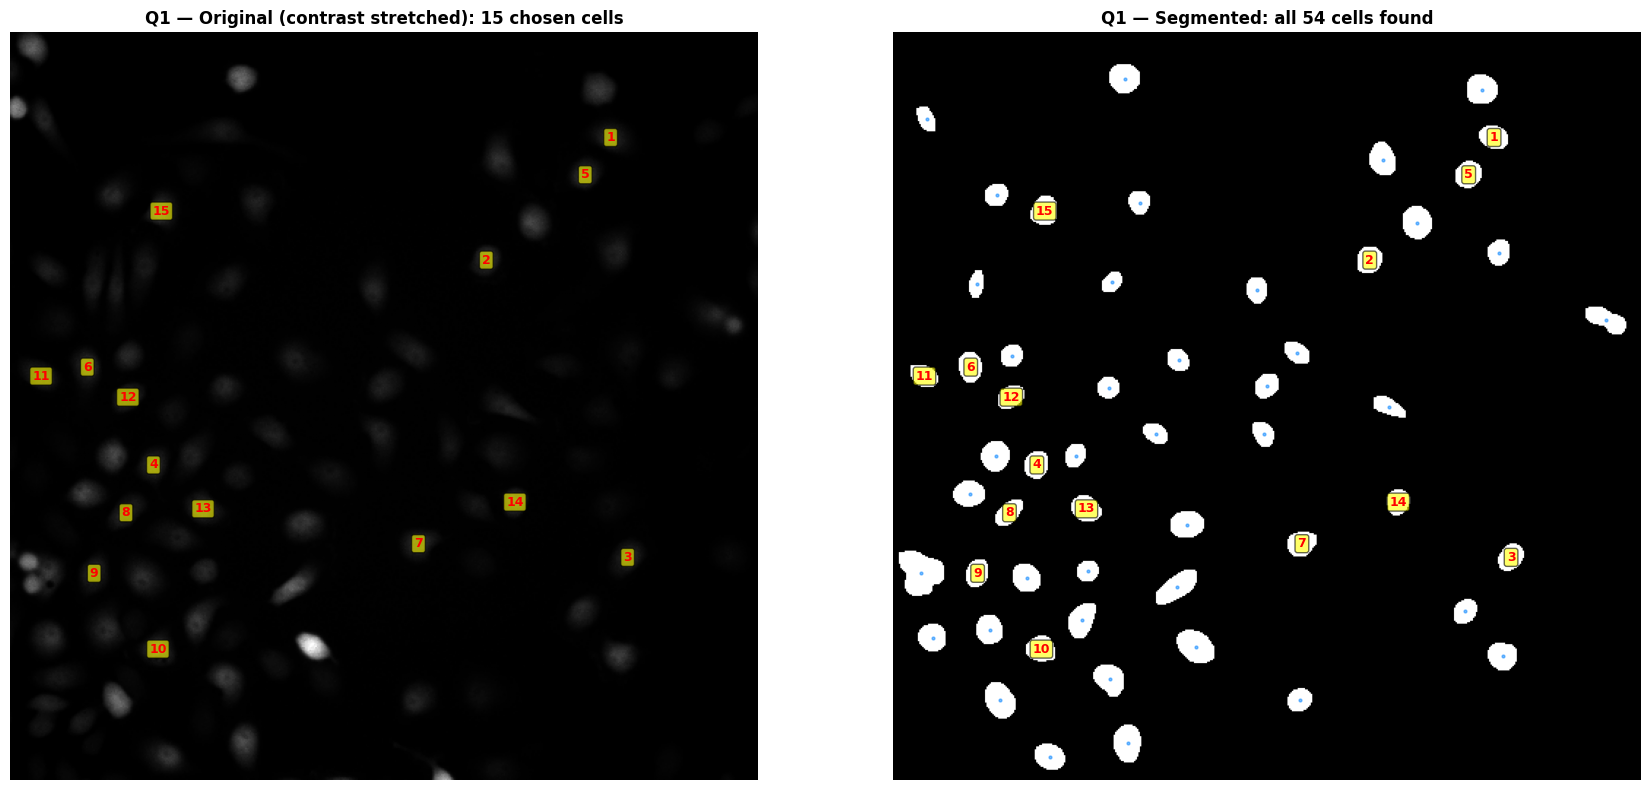

In [ ]:
# Get all cells from the already-segmented frame 0
cells_frame0 = get_centroids(labeled0, img0)
print(f'Cells detected in frame 0: {len(cells_frame0)}')

# Print size distribution to understand the range
sizes = sorted([c['size'] for c in cells_frame0], reverse=True)
print(f'Size range: {min(sizes):.0f} – {max(sizes):.0f}px')
print(f'Median size: {np.median(sizes):.0f}px')

# Pick cells within a plausible single-cell size range
# Too large = likely 2+ merged cells, too small = debris
SIZE_MIN = 200
SIZE_MAX = 469

cells_filtered = [c for c in cells_frame0 
                  if SIZE_MIN <= c['size'] <= SIZE_MAX]
print(f'Cells in size range {SIZE_MIN}-{SIZE_MAX}px: {len(cells_filtered)}')

# Sort by size and pick 15 most medium-sized (closest to median)
median_size = np.median([c['size'] for c in cells_frame0])
cells_filtered_sorted = sorted(cells_filtered,  key=lambda c: abs(c['size'] - median_size))
chosen = cells_filtered_sorted[:15]

chosen_cells = {}
for cell_num, c in enumerate(chosen, start=1):
    chosen_cells[cell_num] = {
        'label_id': c['id'],
        'cx':c['cx'],
        'cy':  c['cy'],
        'size':c['size'],
    }
    print(f'Cell {cell_num:2d}: label={c["id"]}, '
          f'center=({c["cx"]:.1f}, {c["cy"]:.1f}), '
          f'size={c["size"]:.0f}px')

# Visualise: show BOTH original and segmented side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(stretch(arr0), cmap='gray')
axes[0].set_title('Q1 — Original (contrast stretched): 15 chosen cells', fontweight='bold')
axes[0].axis('off')
for cn, info in chosen_cells.items():
    axes[0].text(info['cx'], info['cy'], str(cn), color='red', fontsize=9, fontweight='bold',
                 ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))

# Right: segmented binary with ALL detected cells labeled
seg_arr = np.array(labeled0) > 0
axes[1].imshow(seg_arr, cmap='gray')
axes[1].set_title(f'Q1 — Segmented: all {len(cells_frame0)} cells found', fontweight='bold')
axes[1].axis('off')

# Mark all cells grey, chosen cells red
for c in cells_frame0:
    is_chosen = any(info['label_id'] == c['id'] for info in chosen_cells.values())
    color = 'red'    if is_chosen else 'dodgerblue'
    fc = 'yellow' if is_chosen else 'navy'
    label = str(next(cn for cn, info in chosen_cells.items() 
                      if info['label_id'] == c['id'])) if is_chosen else ''
    if is_chosen:
        axes[1].text(c['cx'], c['cy'], label, color=color, fontsize=9, fontweight='bold',  ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc=fc, alpha=0.6))
    else:
        axes[1].plot(c['cx'], c['cy'], '.', color='dodgerblue', markersize=4, alpha=0.6)

plt.tight_layout()
plt.show()


In [36]:
N_FRAMES = 30
MAX_DIST = 80  # max plausible pixel displacement between 2-minute frames

def track_all_frames(chosen_cells, series_pattern, n_frames=N_FRAMES, max_dist=MAX_DIST):
    """
    Tracks chosen_cells across all frames using nearest-centroid matching.
    
    CRITERI: For each cell at frame t, find the cell in frame t+1 whos centroid is closest (Euclidean distance) within max_dist pixels.
    MOTIVATION: Cancer cells move slowly over 2 minutes so large jumps are biologically implausible. The radius cap prevents mis-assignment to a different distant cell. If no match found, last known position is held.
    Returns: {cell_num: [(cx, cy), ...]} — one (cx,cy) per frame.
    """
    traces = {cn: [(info['cx'], info['cy'])] for cn, info in chosen_cells.items()}
    current_pos = {cn: (info['cx'], info['cy'])   for cn, info in chosen_cells.items()}

    for f in range(1, n_frames):
        img_f, _, labeled_f, _ = segment_cells(series_pattern.format(f))
        cells_f = get_centroids(labeled_f, img_f)

        for cn in chosen_cells:
            prev_cx, prev_cy = current_pos[cn]
            best_dist = max_dist
            best_pos  = None

            for c in cells_f:
                dist = np.sqrt((c['cx'] - prev_cx)**2 + (c['cy'] - prev_cy)**2)
                if dist < best_dist:
                    best_dist = dist
                    best_pos  = (c['cx'], c['cy'])

            if best_pos is not None:
                current_pos[cn] = best_pos
            traces[cn].append(current_pos[cn])

        if f % 5 == 0 or f == n_frames - 1:
            print(f'  Frame {f:02d}/{n_frames-1} done')

    return traces

print('Tracking Control Series (frames 0-29)...')
ctrl_traces = track_all_frames(chosen_cells, 'MTLn3-Ctrl{:04d}.tif')

Tracking Control Series (frames 0-29)...
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done


 ### Question 3 — Manual validation on 5 cells (ground truth check)

 **Validation procedure:**
For 5 cells we overlay the tracked position on 6 evenly-spaced raw frames.

We visually confirm that:
   
   (a) the red dot sits on the correct cell body in each frame
   
   (b) the cyan trace path is spatially smooth and continuous

 A dot landing on the wrong cell or a sudden jump = tracking error for that frame.
 This acts as a ground truth check — we know which cell we started with in frame 0
 and verify the algorithm follows it correctly through the sequence.

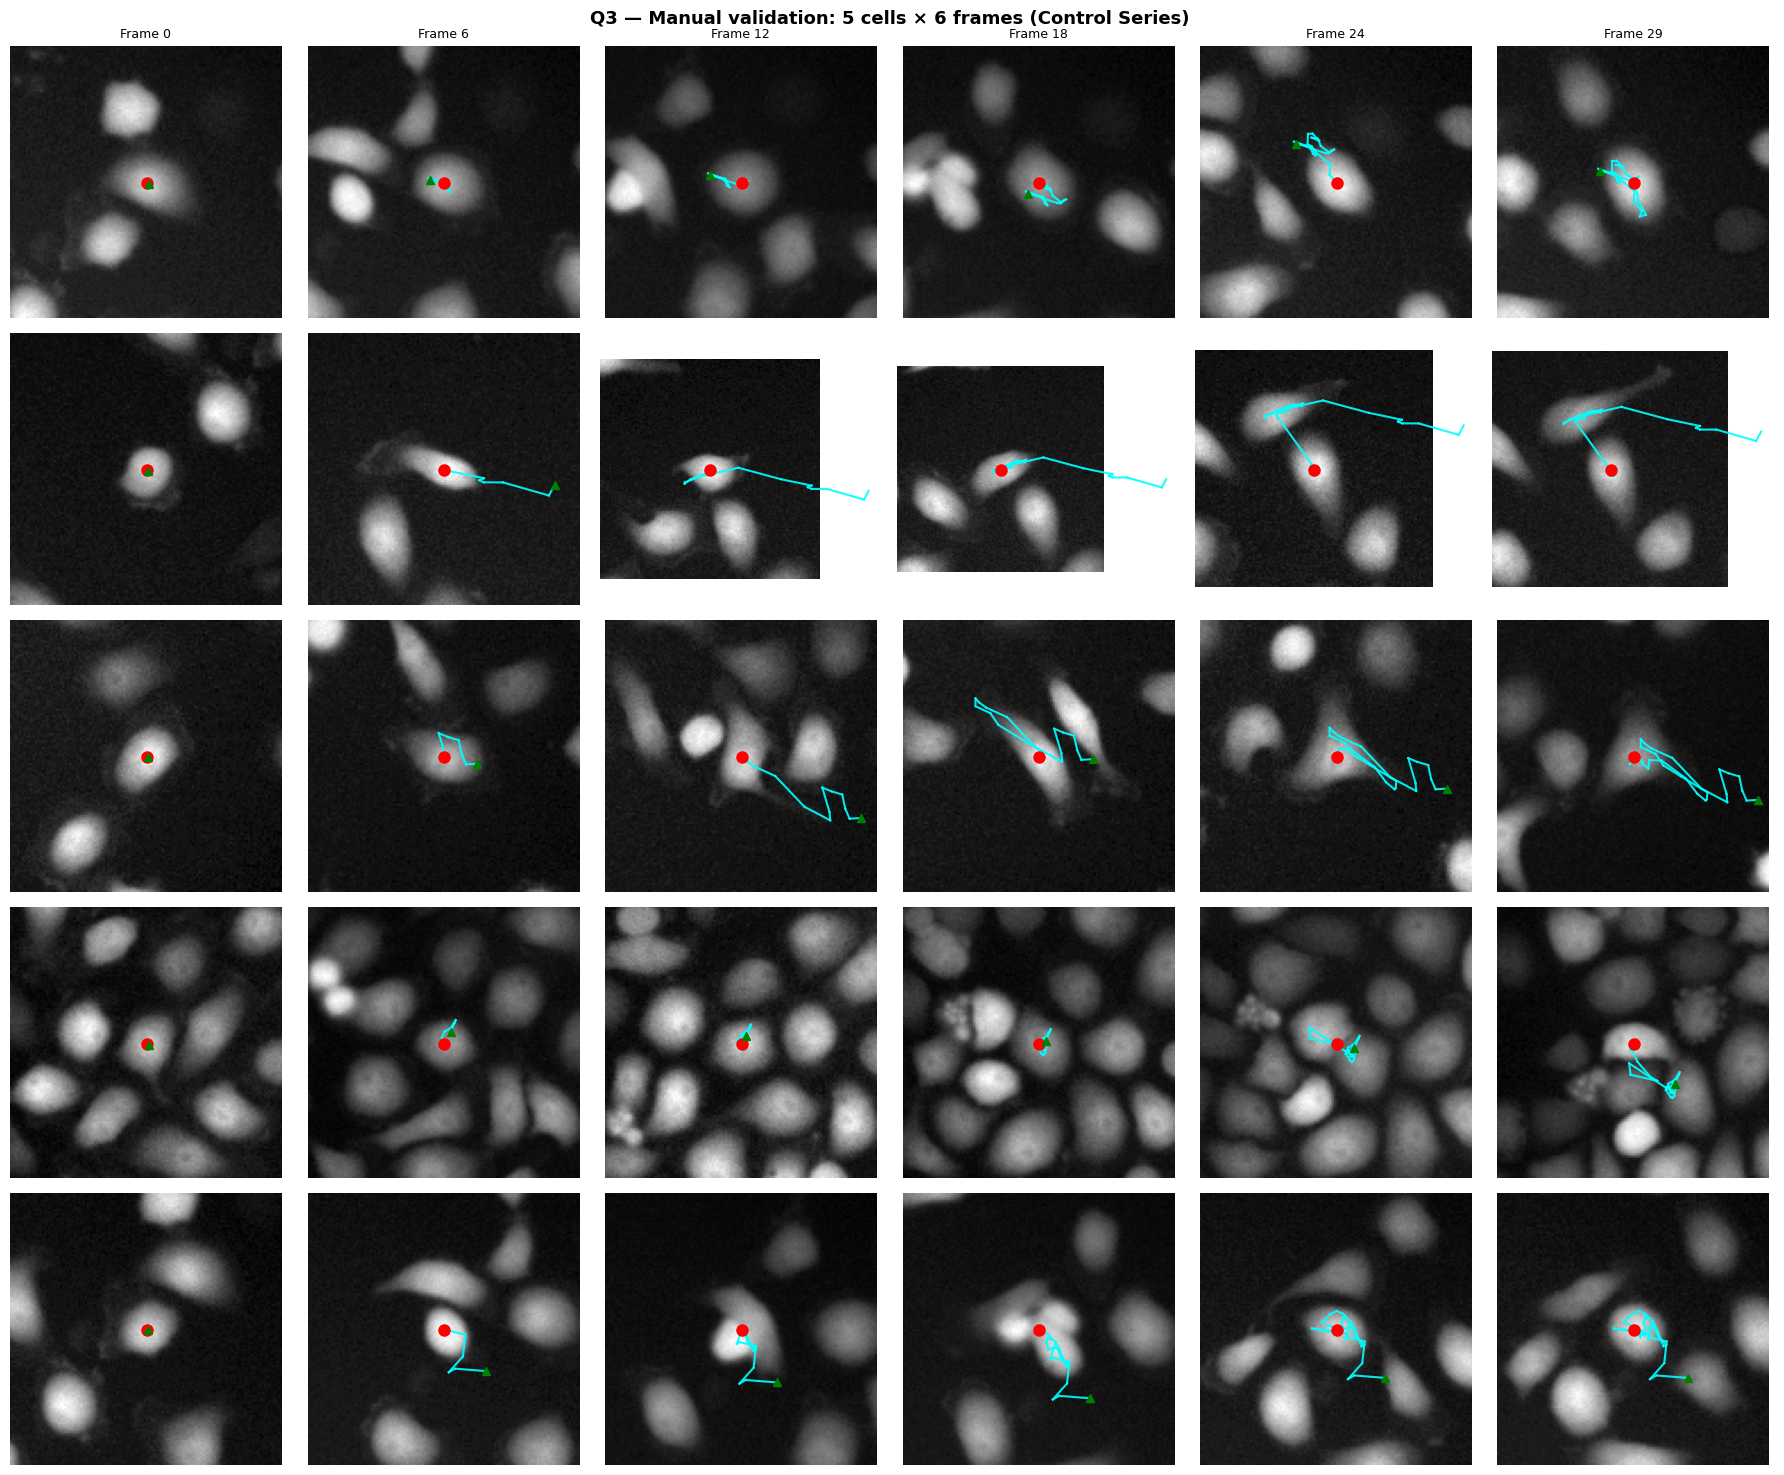

In [35]:
VALIDATE = [1, 2, 3, 4, 5]
CHECK_FRAMES = [0, 6, 12, 18, 24, 29]
ZOOM = 60  # pixels around the cell center to show

fig, axes = plt.subplots(len(VALIDATE), len(CHECK_FRAMES), figsize=(len(CHECK_FRAMES) * 3, len(VALIDATE) * 3))
fig.suptitle('Q3 — Manual validation: 5 cells × 6 frames (Control Series)',
             fontweight='bold', fontsize=13)

for row, cn in enumerate(VALIDATE):
    for col, f in enumerate(CHECK_FRAMES):
        img_f = dip.ImageReadTIFF(f'MTLn3-Ctrl{f:04d}.tif')
        arr_f = np.array(img_f)
        h, w = arr_f.shape[:2]

        # Current tracked position
        cx, cy = ctrl_traces[cn][f]
        cx, cy = int(cx), int(cy)

        # Zoom window — clamp to image bounds
        x0 = max(0, cx - ZOOM);  x1 = min(w, cx + ZOOM)
        y0 = max(0, cy - ZOOM);  y1 = min(h, cy + ZOOM)

        # Crop image to zoom window
        crop = arr_f[y0:y1, x0:x1]

        # Contrast stretch crop for visibility (float32 images are very dark)
        cmin, cmax = crop.min(), crop.max()
        if cmax > cmin:
            crop = (crop - cmin) / (cmax - cmin)

        axes[row, col].imshow(crop, cmap='gray', vmin=0, vmax=1)

        # Re-project trace into crop coordinates
        for i in range(1, f + 1):
            px0, py0 = ctrl_traces[cn][i-1]
            px1, py1 = ctrl_traces[cn][i]
            # Only draw if within zoom window
            axes[row, col].plot( [px0 - x0, px1 - x0], [py0 - y0, py1 - y0], '-', color='cyan', linewidth=1.5, alpha=0.9)

        # Current position marker in crop coords
        axes[row, col].plot(cx - x0, cy - y0, 'ro', markersize=8)

        # Start position marker
        sx, sy = ctrl_traces[cn][0]
        if x0 <= sx <= x1 and y0 <= sy <= y1:
            axes[row, col].plot(sx - x0, sy - y0, 'g^', markersize=6)

        if row == 0:
            axes[row, col].set_title(f'Frame {f}', fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(f'Cell {cn}', fontsize=9, rotation=90, labelpad=4, va='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Question 4 — Apply to 15 cells in Control AND Experimental Series

EGF cells found in frame 0: 37
Size range: 155 – 787px
Median size: 229px
Cells in size range 150-400px: 34
EGF Cell  1: label=33, center=(235.3, 390.9), size=229px
EGF Cell  2: label=10, center=(494.2, 123.7), size=237px
EGF Cell  3: label=21, center=(278.6, 284.5), size=237px
EGF Cell  4: label=27, center=(124.0, 330.2), size=239px
EGF Cell  5: label=24, center=(14.2, 320.2), size=218px
EGF Cell  6: label=25, center=(369.5, 325.4), size=218px
EGF Cell  7: label=20, center=(170.0, 272.9), size=216px
EGF Cell  8: label=23, center=(316.1, 318.0), size=215px
EGF Cell  9: label=18, center=(92.1, 261.5), size=245px
EGF Cell 10: label=6, center=(281.5, 68.4), size=211px
EGF Cell 11: label=29, center=(60.2, 357.1), size=211px
EGF Cell 12: label=22, center=(94.4, 292.3), size=252px
EGF Cell 13: label=2, center=(308.7, 42.6), size=258px
EGF Cell 14: label=14, center=(178.9, 161.6), size=200px
EGF Cell 15: label=16, center=(64.2, 254.4), size=259px


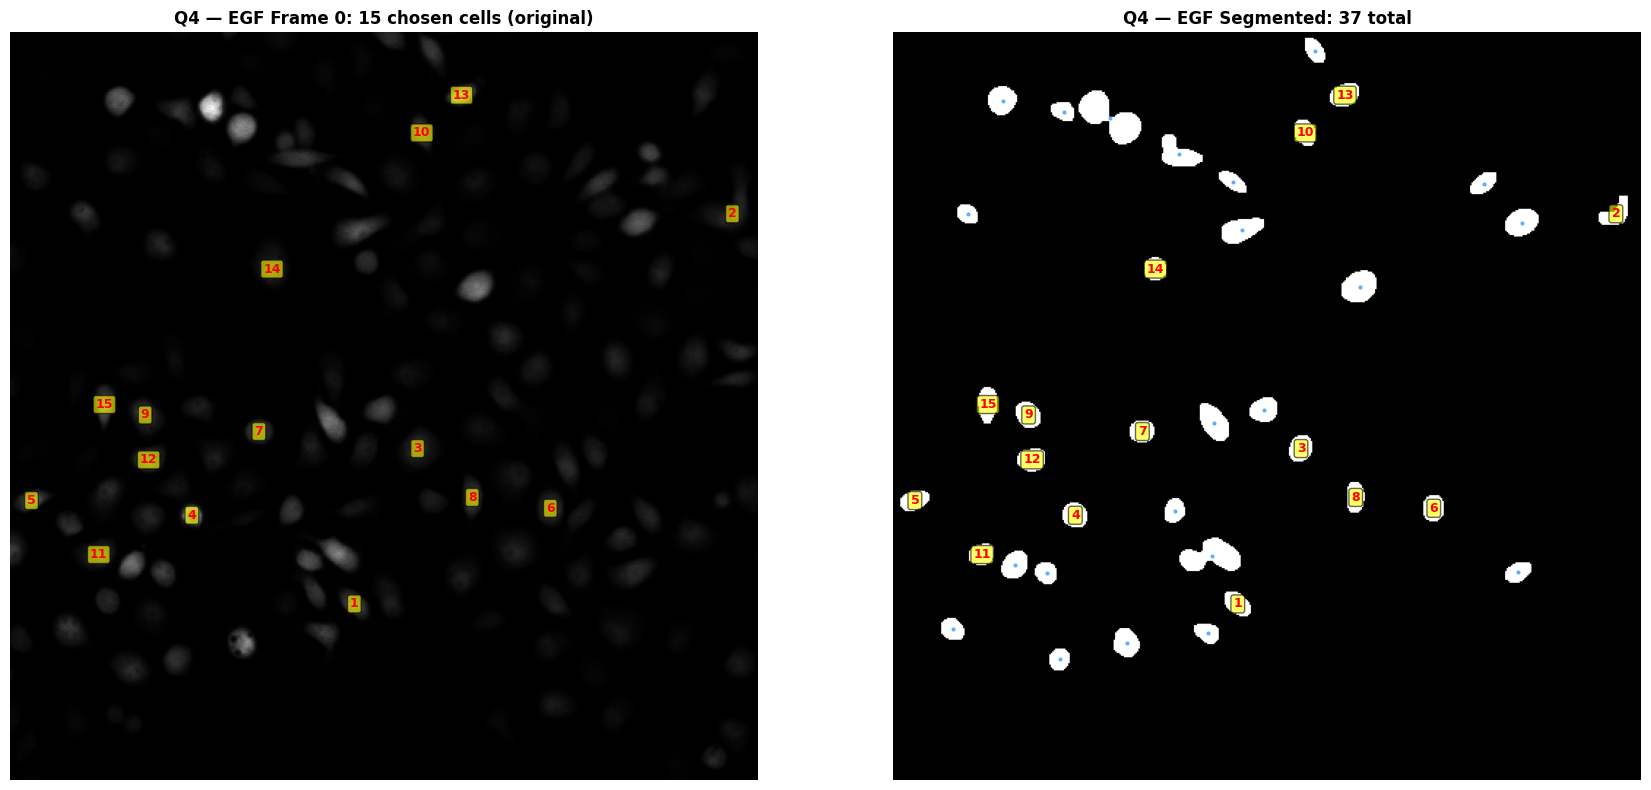

In [34]:
# Pick cells from Experimental frame 0
img0e, _, labeled0e, _ = segment_cells('MTLn3+EGF0000.tif')
arr0e = np.array(img0e)

cells_frame0e = get_centroids(labeled0e, img0e)
print(f'EGF cells found in frame 0: {len(cells_frame0e)}')

# Print size distribution
sizes_e = sorted([c['size'] for c in cells_frame0e], reverse=True)
print(f'Size range: {min(sizes_e):.0f} – {max(sizes_e):.0f}px')
print(f'Median size: {np.median(sizes_e):.0f}px')

# Same size filter as control — exclude merged (too big) and debris (too small)
SIZE_MIN = 150
SIZE_MAX = 400

cells_filtered_e = [c for c in cells_frame0e
                    if SIZE_MIN <= c['size'] <= SIZE_MAX]
print(f'Cells in size range {SIZE_MIN}-{SIZE_MAX}px: {len(cells_filtered_e)}')

# Pick 15 closest to median size
median_size_e = np.median([c['size'] for c in cells_frame0e])
cells_filtered_e_sorted = sorted(cells_filtered_e, key=lambda c: abs(c['size'] - median_size_e))
chosen_e = cells_filtered_e_sorted[:15]

chosen_cells_e = {}
for cn, c in enumerate(chosen_e, start=1):
    chosen_cells_e[cn] = {
        'label_id': c['id'],
        'cx': c['cx'],
        'cy': c['cy'],
        'size':  c['size'],
    }
    print(f'EGF Cell {cn:2d}: label={c["id"]}, '
          f'center=({c["cx"]:.1f}, {c["cy"]:.1f}), '
          f'size={c["size"]:.0f}px')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(stretch(arr0e), cmap='gray')
axes[0].set_title('Q4 — EGF Frame 0: 15 chosen cells (original)', fontweight='bold')
axes[0].axis('off')
for cn, info in chosen_cells_e.items():
    axes[0].text(info['cx'], info['cy'], str(cn), color='red', fontsize=9, fontweight='bold',
                 ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))

axes[1].imshow(np.array(labeled0e) > 0, cmap='gray')
axes[1].set_title(f'Q4 — EGF Segmented: {len(cells_frame0e)} total', fontweight='bold')
axes[1].axis('off')

for c in cells_frame0e:
    is_chosen = any(info['label_id'] == c['id'] for info in chosen_cells_e.values())
    if is_chosen:
        cn_label = str(next(cn for cn, info in chosen_cells_e.items()
                            if info['label_id'] == c['id']))
        axes[1].text(c['cx'], c['cy'], cn_label, color='red', fontsize=9, fontweight='bold', ha='center', va='center', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))
    else:
        axes[1].plot(c['cx'], c['cy'], '.', color='dodgerblue', markersize=4, alpha=0.6)

plt.tight_layout()
plt.show()


Tracking Experimental (+EGF) Series (frames 0-29)
  Frame 05/29 done
  Frame 10/29 done
  Frame 15/29 done
  Frame 20/29 done
  Frame 25/29 done
  Frame 29/29 done


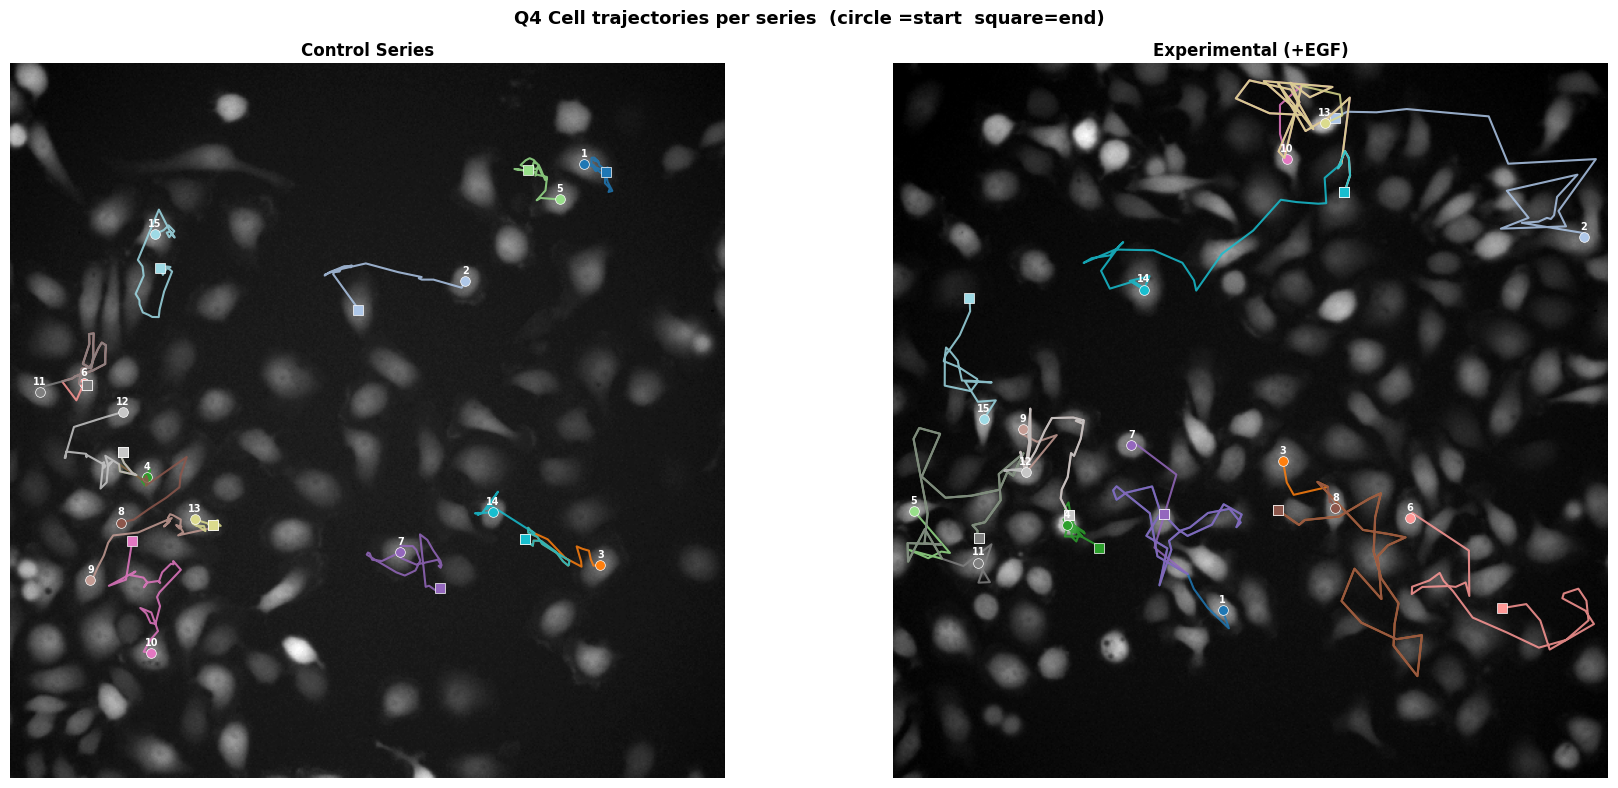

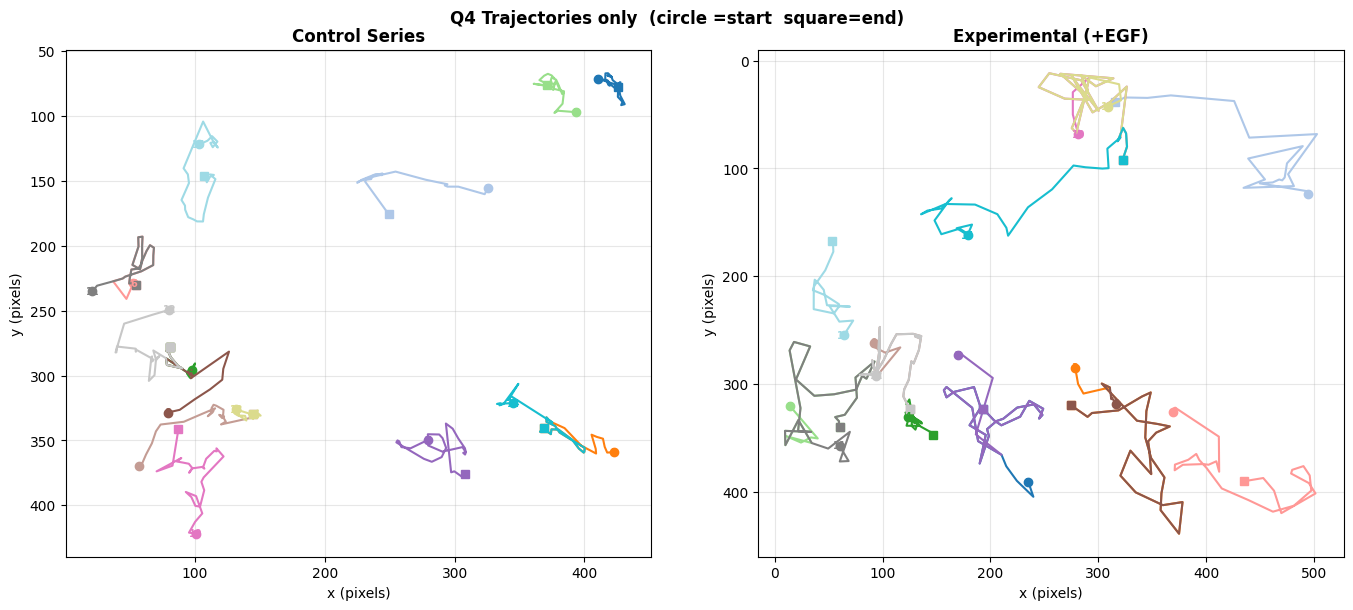

In [33]:
print('Tracking Experimental (+EGF) Series (frames 0-29)')
egf_traces = track_all_frames(chosen_cells_e, 'MTLn3+EGF{:04d}.tif')

# Visualisation 1

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors = plt.cm.tab20(np.linspace(0, 1, 15))

for ax, traces, chosen, title, frame0_file in [
    (axes[0], ctrl_traces, chosen_cells,   'Control Series','MTLn3-Ctrl0000.tif'),
    (axes[1], egf_traces,  chosen_cells_e, 'Experimental (+EGF)', 'MTLn3+EGF0000.tif'),
]:
    bg = stretch(np.array(dip.ImageReadTIFF(frame0_file)))
    ax.imshow(bg, cmap='gray', vmin=0, vmax=1)

    # Only plot cells that exist in this series
    for cn in chosen.keys():
        color = colors[cn - 1]
        xs = [p[0] for p in traces[cn]]
        ys = [p[1] for p in traces[cn]]
        ax.plot(xs, ys, '-',  color=color, linewidth=1.5, alpha=0.85)
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=7, markeredgecolor='white', markeredgewidth=0.5)
        ax.plot(xs[-1], ys[-1], 's', color=color, markersize=7, markeredgecolor='white', markeredgewidth=0.5)
        ax.text(xs[0], ys[0] - 8, str(cn), color='white', fontsize=7, fontweight='bold', ha='center', va='center')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

fig.suptitle('Q4 Cell trajectories per series  (circle =start  square=end)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


# Visualisation 2: Trace-only plot (no background) for clarity

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, traces, chosen, title in [ (axes[0], ctrl_traces, chosen_cells,   'Control Series'), (axes[1], egf_traces,  chosen_cells_e, 'Experimental (+EGF)'), ]:

    for cn in chosen.keys():
        color = colors[cn - 1]
        xs = [p[0] for p in traces[cn]]
        ys = [p[1] for p in traces[cn]]
        ax.plot(xs, ys, '-',  color=color, linewidth=1.5)
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=6)
        ax.plot(xs[-1], ys[-1], 's', color=color, markersize=6)
        ax.text(xs[0], ys[0], str(cn), fontsize=7, fontweight='bold', ha='center', va='center', color=color)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('Q4 Trajectories only  (circle =start  square=end)', fontweight='bold')
plt.tight_layout()
plt.show()
